# Machine Learning Exercise 3
by Thanh Tran, Gero Brunke, Robin-Marcel Hanne

## Task 1: Introduction

/mnt/c/Users/Thanh/Desktop/ML/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/tmp/ipykernel_1554/2286586689.py:140: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:838.)
  train_loss_this_epoch.append(float(loss))


Epoch: 0
Mean Train Loss: 3.90e-01
Mean Test Loss:  2.15e-01
Epoch: 10
Mean Train Loss: 1.49e-01
Mean Test Loss:  3.45e-01
Epoch: 20
Mean Train Loss: 9.67e-02
Mean Test Loss:  5.14e-01
Epoch: 30
Mean Train Loss: 7.12e-02
Mean Test Loss:  4.69e-01
Epoch: 40
Mean Train Loss: 5.84e-02
Mean Test Loss:  6.83e-01
Epoch: 50
Mean Train Loss: 3.54e-02
Mean Test Loss:  7.52e-01
Epoch: 60
Mean Train Loss: 3.07e-02
Mean Test Loss:  7.30e-01
Epoch: 70
Mean Train Loss: 2.20e-02
Mean Test Loss:  8.68e-01
Epoch: 80
Mean Train Loss: 1.75e-02
Mean Test Loss:  1.03e+00
Epoch: 90
Mean Train Loss: 1.78e-02
Mean Test Loss:  1.05e+00
Epoch: 100
Mean Train Loss: 7.48e-03
Mean Test Loss:  9.73e-01


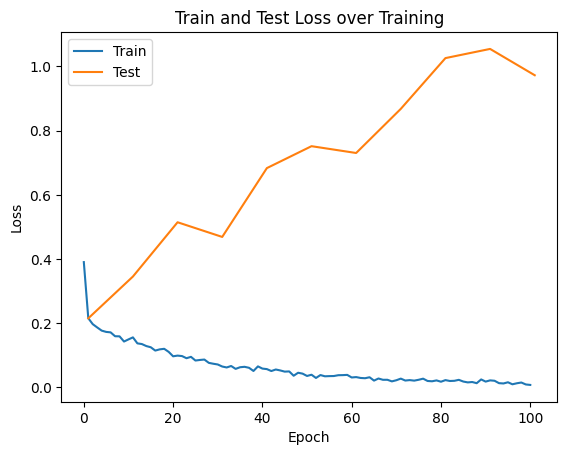

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision.datasets as datasets
import torchvision.transforms as transforms

from torch.nn.functional import conv2d, max_pool2d, cross_entropy

plt.rc("figure", dpi=100)

batch_size = 100

# transform images into normalized tensors
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

train_dataset = datasets.MNIST(
    "./",
    download=True,
    train=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    "./",
    download=True,
    train=False,
    transform=transform,
)

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=1,
    pin_memory=True,
)

test_dataloader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=1,
    pin_memory=True,
)

def init_weights(shape):
    # Kaiming He initialization (a good initialization is important)
    # https://arxiv.org/abs/1502.01852
    std = np.sqrt(2. / shape[0])
    w = torch.randn(size=shape) * std
    w.requires_grad = True
    return w


def rectify(x):
    # Rectified Linear Unit (ReLU)
    return torch.max(torch.zeros_like(x), x)


class RMSprop(optim.Optimizer):
    """
    This is a reduced version of the PyTorch internal RMSprop optimizer
    It serves here as an example
    """
    def __init__(self, params, lr=1e-3, alpha=0.5, eps=1e-8):
        defaults = dict(lr=lr, alpha=alpha, eps=eps)
        super(RMSprop, self).__init__(params, defaults)

    def step(self):
        for group in self.param_groups:
            for p in group['params']:
                grad = p.grad.data
                state = self.state[p]

                # state initialization
                if len(state) == 0:
                    state['square_avg'] = torch.zeros_like(p.data)

                square_avg = state['square_avg']
                alpha = group['alpha']

                # update running averages
                square_avg.mul_(alpha).addcmul_(grad, grad, value=1 - alpha)
                avg = square_avg.sqrt().add_(group['eps'])

                # gradient update
                p.data.addcdiv_(grad, avg, value=-group['lr'])


# define the neural network
def model(x, w_h, w_h2, w_o):
    h = rectify(x @ w_h)
    h2 = rectify(h @ w_h2)
    pre_softmax = h2 @ w_o
    return pre_softmax


# initialize weights

# input shape is (B, 784)
w_h = init_weights((784, 625))
# hidden layer with 625 neurons
w_h2 = init_weights((625, 625))
# hidden layer with 625 neurons
w_o = init_weights((625, 10))
# output shape is (B, 10)

optimizer = RMSprop(params=[w_h, w_h2, w_o])


n_epochs = 100

train_loss = []
test_loss = []

# put this into a training loop over 100 epochs
for epoch in range(n_epochs + 1):
    train_loss_this_epoch = []
    for idx, batch in enumerate(train_dataloader):
        x, y = batch

        # our model requires flattened input
        x = x.reshape(batch_size, 784)
        # feed input through model
        noise_py_x = model(x, w_h, w_h2, w_o)

        # reset the gradient
        optimizer.zero_grad()

        # the cross-entropy loss function already contains the softmax
        loss = cross_entropy(noise_py_x, y, reduction="mean")

        train_loss_this_epoch.append(float(loss))

        # compute the gradient
        loss.backward()
        # update weights
        optimizer.step()

    train_loss.append(np.mean(train_loss_this_epoch))

    # test periodically
    if epoch % 10 == 0:
        print(f"Epoch: {epoch}")
        print(f"Mean Train Loss: {train_loss[-1]:.2e}")
        test_loss_this_epoch = []

        # no need to compute gradients for validation
        with torch.no_grad():
            for idx, batch in enumerate(test_dataloader):
                x, y = batch
                x = x.reshape(batch_size, 784)
                noise_py_x = model(x, w_h, w_h2, w_o)

                loss = cross_entropy(noise_py_x, y, reduction="mean")
                test_loss_this_epoch.append(float(loss))

        test_loss.append(np.mean(test_loss_this_epoch))

        print(f"Mean Test Loss:  {test_loss[-1]:.2e}")

plt.plot(np.arange(n_epochs + 1), train_loss, label="Train")
plt.plot(np.arange(1, n_epochs + 2, 10), test_loss, label="Test")
plt.title("Train and Test Loss over Training")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

## Task 2: Dropout

In [2]:
def dropout(X, p_drop=0.5):
    if p_drop <= 0 or p_drop >= 1:
        return X

    mask = torch.bernoulli(torch.full_like(X, p_drop))

    return (X * (1 - mask)) / (1 - p_drop)

<div style="color: green; font-weight: bold"> Our implementation is correct.

Compared to the sample solution, which uses a boolean mask and in-place zeroing, our version uses multiplicative masking but both approaches are mathematically equivalent.</div>

In [3]:
def dropout_model(X, w_h, w_h2, w_o, p_drop_input=0.2, p_drop_hidden=0.5):
    X = dropout(X, p_drop_input)
    h = rectify(X @ w_h)
    h = dropout(h, p_drop_hidden)
    h2 = rectify(h @ w_h2)
    h2 = dropout(h2, p_drop_hidden)
    pre_softmax = h2 @ w_o
    return pre_softmax

<div style="color: green; font-weight: bold">The code is equal to the sample solution for the dropout model.</div>

Epoch: 0
Mean Train Loss: 7.45e-01
Mean Test Loss:  2.36e-01
Epoch: 10
Mean Train Loss: 6.93e-01
Mean Test Loss:  2.20e-01
Epoch: 20
Mean Train Loss: 8.72e-01
Mean Test Loss:  2.86e-01
Epoch: 30
Mean Train Loss: 9.27e-01
Mean Test Loss:  3.14e-01
Epoch: 40
Mean Train Loss: 1.03e+00
Mean Test Loss:  4.09e-01
Epoch: 50
Mean Train Loss: 1.16e+00
Mean Test Loss:  3.87e-01
Epoch: 60
Mean Train Loss: 1.18e+00
Mean Test Loss:  3.62e-01
Epoch: 70
Mean Train Loss: 1.24e+00
Mean Test Loss:  4.88e-01
Epoch: 80
Mean Train Loss: 1.34e+00
Mean Test Loss:  4.99e-01
Epoch: 90
Mean Train Loss: 1.28e+00
Mean Test Loss:  5.62e-01
Epoch: 100
Mean Train Loss: 1.45e+00
Mean Test Loss:  6.15e-01


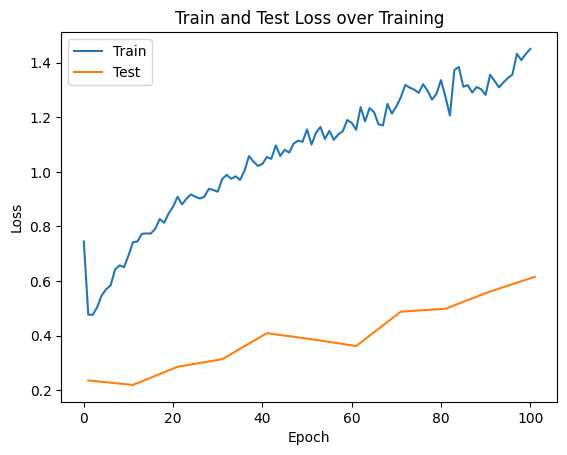

In [4]:
# initialize weights

# input shape is (B, 784)
w_h = init_weights((784, 625))
# hidden layer with 625 neurons
w_h2 = init_weights((625, 625))
# hidden layer with 625 neurons
w_o = init_weights((625, 10))
# output shape is (B, 10)

optimizer = RMSprop(params=[w_h, w_h2, w_o])


n_epochs = 100

train_loss = []
test_loss = []

# put this into a training loop over 100 epochs
for epoch in range(n_epochs + 1):
    train_loss_this_epoch = []
    for idx, batch in enumerate(train_dataloader):
        x, y = batch

        # our model requires flattened input
        x = x.reshape(batch_size, 784)
        # feed input through model
        noise_py_x = dropout_model(x, w_h, w_h2, w_o)

        # reset the gradient
        optimizer.zero_grad()

        # the cross-entropy loss function already contains the softmax
        loss = cross_entropy(noise_py_x, y, reduction="mean")

        train_loss_this_epoch.append(float(loss))

        # compute the gradient
        loss.backward()
        # update weights
        optimizer.step()

    train_loss.append(np.mean(train_loss_this_epoch))

    # test periodically
    if epoch % 10 == 0:
        print(f"Epoch: {epoch}")
        print(f"Mean Train Loss: {train_loss[-1]:.2e}")
        test_loss_this_epoch = []

        # no need to compute gradients for validation
        with torch.no_grad():
            for idx, batch in enumerate(test_dataloader):
                x, y = batch
                x = x.reshape(batch_size, 784)
                noise_py_x = model(x, w_h, w_h2, w_o)

                loss = cross_entropy(noise_py_x, y, reduction="mean")
                test_loss_this_epoch.append(float(loss))

        test_loss.append(np.mean(test_loss_this_epoch))

        print(f"Mean Test Loss:  {test_loss[-1]:.2e}")

plt.plot(np.arange(n_epochs + 1), train_loss, label="Train")
plt.plot(np.arange(1, n_epochs + 2, 10), test_loss, label="Test")
plt.title("Train and Test Loss over Training")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

<div style="color: green; font-weight: bold">The evaluation is essentially the same.
A minor difference is that dropout is not explicitly disabled by setting probabilities to zero in the test loop but we rather just call model from task 1 again. This is still correct, since p_drop_nd p_drop_hidden are zero thus we will return the same result as the model function from task 1. Nevertheless, it probably would have been better to explicitly use the dropout_model function with the last two parameters set to zero for clarity.</div>

### How the dropout method works and how it reduces overfitting
Dropout works by randomly setting a fraction of the activations in a layer to zero during training. Because neurons cannot rely on the presence of specific other neurons, the model is forced to learn more robust and redundant features instead of memorizing patterns tied to particular activations. This reduces overfitting by preventing co-adaptation of neurons.

### Why we need a different model configuration for evaluating the test loss
We need a different model configuration for evaluating the test loss because dropout introduces randomness during training by removing activations, but at test time we want deterministic and consistent predictions using the full network. If dropout were still active during evaluation, the output would vary randomly for the same input, making the test loss unreliable. Therefore, dropout is disabled during testing so that all neurons contribute and the learned weights are used at full capacity.

### Comparison of the errors from Section 1
In the first model without dropout, the training loss decreases strongly and continuously down to very small values, while the test loss initially decreases but then steadily increases after around epoch 10–20. The model overfits heavily.

In the dropout model, the training loss stays significantly higher and does not decrease nearly as much, which is expected because dropout makes the optimization task harder by randomly removing parts of the network during training. However, the important difference is that the test loss is lower and much more stable across epochs.

Compared to the first model in Section 1, the dropout model clearly reduces overfitting. While the baseline model achieves a lower training loss, it ends up with a much worse final test loss, whereas the dropout model maintains a substantially lower and more stable test loss. This shows that dropout improves generalization at the cost of higher training error.

<div style="color: green; font-weight: bold">Our answer is correct and broadly consistent with the sample solution, but more detailed in its explanations.</div>

## Task 3: Parametric Relu

Implementing the PreLU function

$x_i \rightarrow
    \begin{cases}
    x_i      & x_i > 0\\
    a_i x_i  & x_i \leq 0
    \end{cases}
$

In [5]:
def PReLU ( X, a ):
    """
    Parametric rectified Linear Unit
    Applies X if X >Y 0 and x * X if X <= 0
    """
    return torch.where( X > 0, X, a * X )

<div style="color: green; font-weight: bold">PReLU implementation itself correct</div>

And updated model architecutre with PRelu instead of recify - this will rely on task 1

In [ ]:
def PReLU_model(x, w_h, w_h2, w_o, a_h, a_h2):
    # 1st layer
    h = PReLU(x @ w_h, a_h)

    # 2nd layer (hidden)
    h2 = PReLU(h @ w_h2, a_h2)

    pre_smx = h2 @ w_o
    return pre_smx

<div style="color: green; font-weight: bold">We were not using dropout here, which might explain the divergence from the solution down the line.</div>

Training requires grad so new torches

Epoch: 0
Mean Train Loss: 4.68e-01
Mean Test Loss:  1.73e-01
Epoch: 10
Mean Train Loss: 1.09e-01
Mean Test Loss:  2.16e-01
Epoch: 20
Mean Train Loss: 7.57e-02
Mean Test Loss:  3.07e-01
Epoch: 30
Mean Train Loss: 6.09e-02
Mean Test Loss:  3.57e-01
Epoch: 40
Mean Train Loss: 5.20e-02
Mean Test Loss:  3.65e-01
Epoch: 50
Mean Train Loss: 4.50e-02
Mean Test Loss:  4.26e-01
Epoch: 60
Mean Train Loss: 3.82e-02
Mean Test Loss:  5.07e-01
Epoch: 70
Mean Train Loss: 3.74e-02
Mean Test Loss:  4.84e-01
Epoch: 80
Mean Train Loss: 3.60e-02
Mean Test Loss:  6.01e-01
Epoch: 90
Mean Train Loss: 3.34e-02
Mean Test Loss:  5.75e-01
Epoch: 100
Mean Train Loss: 3.14e-02
Mean Test Loss:  6.80e-01


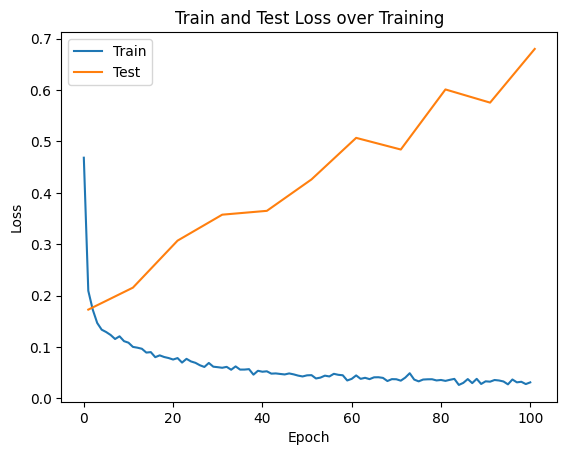

In [7]:
# initialize weights

# input shape is (B, 784)
w_h = init_weights((784, 625))
# hidden layer with 625 neurons
w_h2 = init_weights((625, 625))
# hidden layer with 625 neurons
w_o = init_weights((625, 10))
# output shape is (B, 10)

a_h = torch.full((625,), 0.25, requires_grad=True)
a_h2 = torch.full((625,), 0.25, requires_grad=True)

# including a_h and a_h2

optimizer = RMSprop(params=[w_h, w_h2, w_o, a_h, a_h2])

n_epochs = 100

train_loss = []
test_loss = []

# put this into a training loop over 100 epochs
for epoch in range(n_epochs + 1):
    train_loss_this_epoch = []
    for idx, batch in enumerate(train_dataloader):
        x, y = batch

        # our model requires flattened input
        x = x.reshape(batch_size, 784)
        # feed input through model
        noise_py_x = PReLU_model(x, w_h, w_h2, w_o, a_h, a_h2)

        # reset the gradient
        optimizer.zero_grad()

        # the cross-entropy loss function already contains the softmax
        loss = cross_entropy(noise_py_x, y, reduction="mean")

        train_loss_this_epoch.append(float(loss))

        # compute the gradient
        loss.backward()
        # update weights
        optimizer.step()

    train_loss.append(np.mean(train_loss_this_epoch))

    # test periodically
    if epoch % 10 == 0:
        print(f"Epoch: {epoch}")
        print(f"Mean Train Loss: {train_loss[-1]:.2e}")
        test_loss_this_epoch = []

        # no need to compute gradients for validation
        with torch.no_grad():
            for idx, batch in enumerate(test_dataloader):
                x, y = batch
                x = x.reshape(batch_size, 784)
                noise_py_x = PReLU_model(x, w_h, w_h2, w_o, a_h, a_h2)

                loss = cross_entropy(noise_py_x, y, reduction="mean")
                test_loss_this_epoch.append(float(loss))

        test_loss.append(np.mean(test_loss_this_epoch))

        print(f"Mean Test Loss:  {test_loss[-1]:.2e}")

plt.plot(np.arange(n_epochs + 1), train_loss, label="Train")
plt.plot(np.arange(1, n_epochs + 2, 10), test_loss, label="Test")
plt.title("Train and Test Loss over Training")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

<div style="color: green; font-weight: bold">Logically correct, and probably also correctly implemented, however the dropout part was not added in the PReLU_model method and thus no paramters like p_drop_input and p_drop_hidden are in the method calls here. This could potentially explain the different test loss curve. The training curve however is nearly identical.</div>

# Comparing
 - **Compared to task 1:** The PReLU converges slightly faster and achieves a lower training loss. Because the negative inputs do not lead to a 0 less nuerons die leading to a higher learning capacity.

 - **Compared to task 2:** The PReLU doesn't regularize the network like the Dropout does. It might overfit despite being a lower training error.

## Task 4

Epoch: 0
Mean Train Loss: 1.84e+00
Mean Test Loss: 5.22e-01
Test Accuracy: 90.37%
Test Error:    9.63%
Mean Test Loss:  5.22e-01
Epoch: 10
Mean Train Loss: 1.47e-01
Mean Test Loss: 4.01e-02
Test Accuracy: 98.73%
Test Error:    1.27%
Mean Test Loss:  4.01e-02
Epoch: 20
Mean Train Loss: 8.82e-02
Mean Test Loss: 2.59e-02
Test Accuracy: 99.20%
Test Error:    0.80%
Mean Test Loss:  2.59e-02
Epoch: 30
Mean Train Loss: 6.75e-02
Mean Test Loss: 2.45e-02
Test Accuracy: 99.22%
Test Error:    0.78%
Mean Test Loss:  2.45e-02
Epoch: 40
Mean Train Loss: 5.74e-02
Mean Test Loss: 1.87e-02
Test Accuracy: 99.52%
Test Error:    0.48%
Mean Test Loss:  1.87e-02
Epoch: 50
Mean Train Loss: 4.87e-02
Mean Test Loss: 1.74e-02
Test Accuracy: 99.43%
Test Error:    0.57%
Mean Test Loss:  1.74e-02
Epoch: 60
Mean Train Loss: 4.60e-02
Mean Test Loss: 1.89e-02
Test Accuracy: 99.41%
Test Error:    0.59%
Mean Test Loss:  1.89e-02
Epoch: 70
Mean Train Loss: 4.10e-02
Mean Test Loss: 1.76e-02
Test Accuracy: 99.47%
Test Err

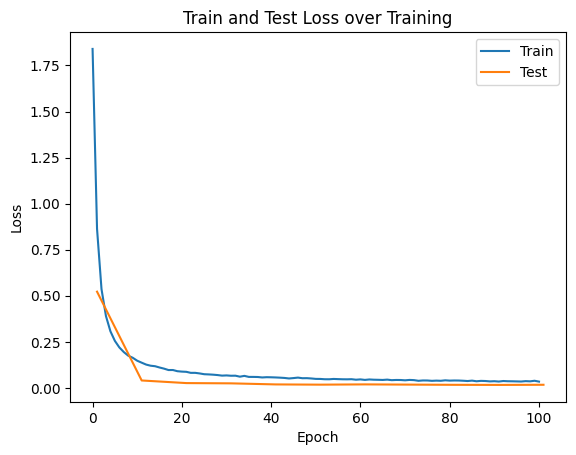

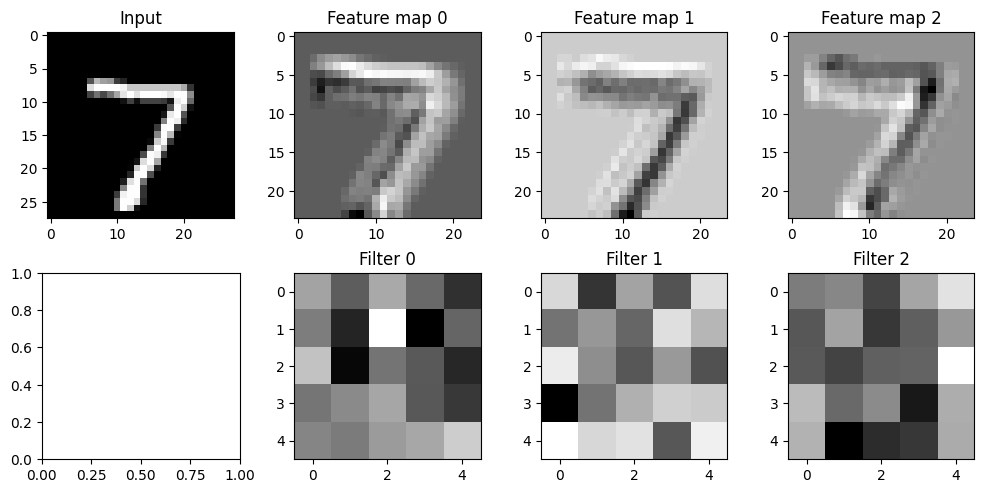

In [8]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision.datasets as datasets
import torchvision.transforms as transforms

from torch.nn.functional import conv2d, max_pool2d, cross_entropy, dropout

plt.rc("figure", dpi=100)

batch_size = 100

# transform images into normalized tensors
train_transform = transforms.Compose([
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(
    "./",
    download=True,
    train=True,
    transform=train_transform,
)

test_dataset = datasets.MNIST(
    "./",
    download=True,
    train=False,
    transform=test_transform,
)

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=1,
    pin_memory=True,
)

test_dataloader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=1,
    pin_memory=True,
)

def init_weights(shape):
    if len(shape) == 2:
        fan_in = shape[0]
    else:
        fan_in = np.prod(shape[1:])

    std = np.sqrt(2.0 / fan_in)
    w = torch.randn(shape) * std
    w.requires_grad = True

    return w


def rectify(x):
    # Rectified Linear Unit (ReLU)
    return torch.max(torch.zeros_like(x), x)


class RMSprop(optim.Optimizer):
    """
    This is a reduced version of the PyTorch internal RMSprop optimizer
    It serves here as an example
    """
    def __init__(self, params, lr=1e-3, alpha=0.5, eps=1e-8):
        defaults = dict(lr=lr, alpha=alpha, eps=eps)
        super(RMSprop, self).__init__(params, defaults)

    def step(self):
        for group in self.param_groups:
            for p in group['params']:
                grad = p.grad.data
                state = self.state[p]

                # state initialization
                if len(state) == 0:
                    state['square_avg'] = torch.zeros_like(p.data)

                square_avg = state['square_avg']
                alpha = group['alpha']

                # update running averages
                square_avg.mul_(alpha).addcmul_(grad, grad, value=1 - alpha)
                avg = square_avg.sqrt().add_(group['eps'])

                # gradient update
                p.data.addcdiv_(grad, avg, value=-group['lr'])


# define the neural network
def model(x, w_c1, w_c2, w_c3, w_h2, w_o, training=True, p_drop_input=0.2, p_drop_hidden=0.5):
    h1 = rectify(conv2d(x, w_c1))
    h1 = max_pool2d(h1, (2, 2))
    h1 = dropout(h1, p=p_drop_input, training=training)

    h2 = rectify(conv2d(h1, w_c2))
    h2 = max_pool2d(h2, (2, 2))
    h2 = dropout(h2, p=p_drop_input, training=training)

    h3 = rectify(conv2d(h2, w_c3))
    h3 = dropout(h3, p=p_drop_hidden, training=training)

    h3 = torch.reshape(h3, (h3.shape[0], -1))

    h4 = rectify(h3 @ w_h2)
    h4 = dropout(h4, p=p_drop_hidden, training=training)

    pre_softmax = h4 @ w_o

    return pre_softmax

def main():
    # initialize weights

    # input shape is (B, 784)
    w_c1 = init_weights((32, 1, 5, 5))
    w_c2 = init_weights((64, 32, 5, 5))
    w_c3 = init_weights((128, 64, 3, 3))

    w_h2 = init_weights((512, 625))
    w_o = init_weights((625, 10))
    # output shape is (B, 10)

    optimizer = RMSprop(params=[w_c1, w_c2, w_c3, w_h2, w_o], lr=1e-4, alpha=0.99)
    n_epochs = 100

    train_loss = []
    test_loss = []

    # put this into a training loop over 100 epochs
    for epoch in range(n_epochs + 1):
        train_loss_this_epoch = []
        for idx, batch in enumerate(train_dataloader):
            x, y = batch

            # our model requires flattened input
            x = x.reshape(-1, 1, 28, 28)
            # feed input through model
            noise_py_x = model(x, w_c1, w_c2, w_c3, w_h2, w_o, training=True)

            # reset the gradient
            optimizer.zero_grad()

            # the cross-entropy loss function already contains the softmax
            loss = cross_entropy(noise_py_x, y, reduction="mean")

            train_loss_this_epoch.append(loss.detach().item())

            # compute the gradient
            loss.backward()
            # update weights
            optimizer.step()

        train_loss.append(np.mean(train_loss_this_epoch))

        # test periodically
        if epoch % 10 == 0:
            print(f"Epoch: {epoch}")
            print(f"Mean Train Loss: {train_loss[-1]:.2e}")
            test_loss_this_epoch = []

            # no need to compute gradients for validation
            correct = 0
            total = 0
            with torch.no_grad():
                for idx, batch in enumerate(test_dataloader):
                    x, y = batch
                    x = x.reshape(-1, 1, 28, 28)
                    noise_py_x = model(x, w_c1, w_c2, w_c3, w_h2, w_o, training=False)

                    loss = cross_entropy(noise_py_x, y, reduction="mean")
                    test_loss_this_epoch.append(loss.detach().item())
                    pred = torch.argmax(noise_py_x, dim=1)

                    correct += (pred == y).sum().item()
                    total += y.size(0)

            test_loss.append(np.mean(test_loss_this_epoch))
            accuracy = correct / total
            test_error = 1 - accuracy

            print(f"Mean Test Loss: {test_loss[-1]:.2e}")
            print(f"Test Accuracy: {100 * accuracy:.2f}%")
            print(f"Test Error:    {100 * test_error:.2f}%")
            print(f"Mean Test Loss:  {test_loss[-1]:.2e}")

    plt.plot(np.arange(n_epochs + 1), train_loss, label="Train")
    plt.plot(np.arange(1, n_epochs + 2, 10), test_loss, label="Test")
    plt.title("Train and Test Loss over Training")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # plot one image with convolution
    with torch.no_grad():
        x, y = next(iter(test_dataloader))
        image = x[0:1]
        conv_output = conv2d(image, w_c1)
        fig, ax = plt.subplots(2, 4, figsize=(10, 5))

        ax[0, 0].imshow(image[0, 0].numpy(), cmap="gray")
        ax[0, 0].set_title("Input")

        for i in range(3):
            ax[0, i + 1].imshow(conv_output[0, i].numpy(), cmap="gray")
            ax[0, i + 1].set_title(f"Feature map {i}")

            ax[1, i + 1].imshow(w_c1[i, 0].detach().numpy(), cmap="gray")
            ax[1, i + 1].set_title( f"Filter {i}")

        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    main()

<div style="color: green; font-weight: bold">Our implementation is correct. The images for the number 7 and the filters look very similar to the provided solution. Also, the plot of the training and test loss yields similar results, both converge at about 0.2 with test loss being slightly less. Conceptually our code is the same as the provided one, however, variables for convolution and drop etc. are called different (i.e. the sample h_2 is out h_4). In addition, the worked example chose a different task in 4.2 as one only had to choose one of the given ones, so we cannot compare them here</div>